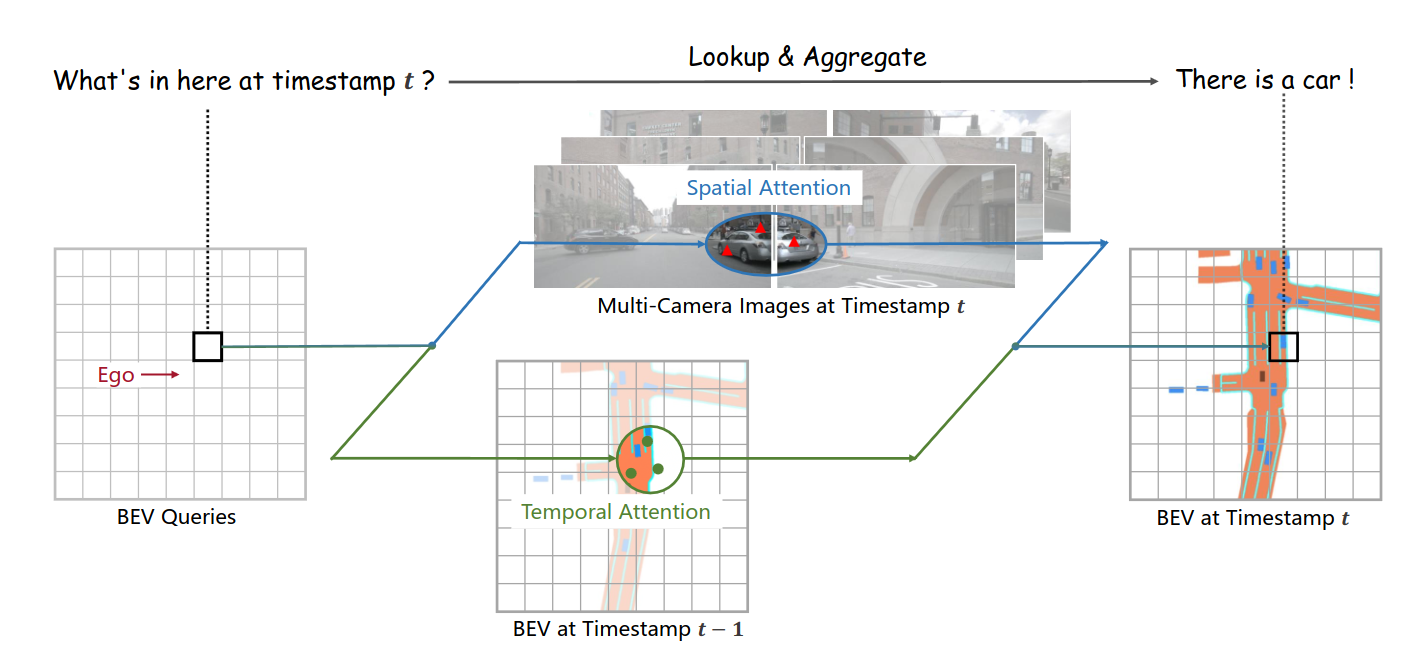

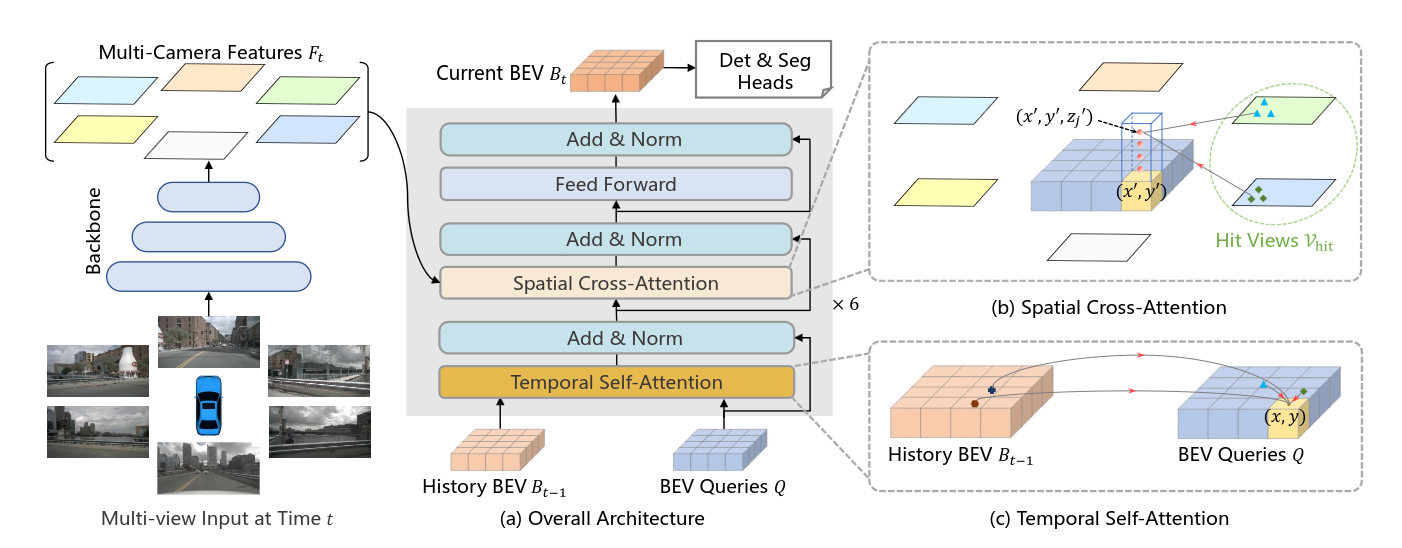

# BEVFormer: Learning Bird's-Eye-View Representation from Multi-Camera Images via Spatiotemporal Transformers 论文详解

## 一、论文概况与核心思想

这篇题为 **《BEVFormer: Learning Bird's-Eye-View Representation from Multi-Camera Images via Spatiotemporal Transformers》** 的论文发表于 ECCV 2022，由上海人工智能实验室、南京大学、香港大学等机构联合提出。其核心思想是：

- 提出一种基于 **时空 Transformer** 的鸟瞰图（BEV）特征生成方法，从多相机图像中学习统一的 BEV 表示，用于自动驾驶的 3D 感知任务（如 3D 目标检测、地图分割）。
- 通过预定义的**网格状 BEV 查询（BEV Queries）**，利用**空间交叉注意力（Spatial Cross-Attention）** 从多视角图像中聚合空间特征，利用**时间自注意力（Temporal Self-Attention）** 从历史 BEV 特征中聚合时序信息，从而生成当前时刻的强大 BEV 特征。
- 在 nuScenes 和 Waymo 数据集上大幅超越以往纯视觉方法，甚至在某些指标上接近或达到 LiDAR 方法的水平。

BEVFormer 成为后续大量端到端自动驾驶工作的基础 BEV 编码器，如 UniAD、VAD 等。

---

## 二、背景与动机

### 2.1 多相机 3D 感知的挑战

自动驾驶需要从多相机图像中理解 3D 环境。早期的单目检测方法对不同视角独立处理，然后跨相机后处理，但这种方法**无法跨相机共享信息**，导致性能低下。为了统一多相机信息，**BEV（鸟瞰图）表示**应运而生，它能够清楚地呈现物体的位置和尺度，适合多种下游任务（检测、分割、规划）。

然而，从 2D 图像生成 BEV 是一个病态问题（ill-posed），因为缺乏深度信息。现有方法主要依赖于**深度估计**或**深度分布**来投影特征，但这些方法对深度精度敏感，容易产生累积误差。

### 2.2 Transformer 与注意力机制的启发

Transformer 通过注意力机制动态聚合有价值的信息，不依赖于显式的 3D 先验。BEVFormer 的核心动机就是**利用注意力机制自适应地学习 BEV 特征**，而不是严格依赖深度值。

此外，时序信息对人类视觉感知至关重要（例如推断运动速度、识别被遮挡物体），但当时的多相机 3D 检测方法很少利用时序信息。挑战在于自动驾驶是实时系统，场景变化快，简单堆叠多帧 BEV 特征会带来额外计算开销和干扰信息。因此，BEVFormer 借鉴 RNN 的思想，用**时间自注意力**递归地传递历史 BEV 特征，只增加少量计算。

### 2.3 BEVFormer 的三个关键设计

1. **网格状 BEV 查询**：作为可学习的参数，负责查询 BEV 空间中的特征。
2. **空间交叉注意力**：每个 BEV 查询只与多相机图像中感兴趣区域的特征交互，高效聚合空间信息。
3. **时间自注意力**：每个 BEV 查询与历史 BEV 特征对齐后交互，提取时序信息。

---

## 三、方法详解

### 3.1 总体架构

BEVFormer 包含 6 个编码器层，每层由三部分组成：时间自注意力、空间交叉注意力、前馈网络。整体流程如图 2 所示。

- **输入**：当前时刻 $ t $ 的多视角图像特征 $ F_t = \{F_t^i\}_{i=1}^{N_{view}} $（由骨干网络提取），以及上一时刻的 BEV 特征 $ B_{t-1} $。
- **编码器层**：
  1. BEV 查询 $ Q $ 先通过**时间自注意力**从历史 BEV $ B_{t-1} $ 中查询时序信息。
  2. 然后通过**空间交叉注意力**从多相机特征 $ F_t $ 中查询空间信息。
  3. 经过前馈网络后，输出精炼的 BEV 特征。
- **输出**：经过 6 层堆叠，生成当前时刻的 BEV 特征 $ B_t $，供 3D 检测头和地图分割头使用。

### 3.2 BEV Queries（BEV 查询）

- BEV 查询 $ Q \in \mathbb{R}^{H \times W \times C} $ 是一组**网格状的可学习参数**，$ H, W $ 是 BEV 平面的空间尺寸，$ C $ 是特征维度。
- 每个查询 $ Q_p $（位于 $ p=(x,y) $）负责 BEV 平面上对应的网格单元区域。每个网格对应真实世界中 $ s $ 米的大小（默认 $ s=0.512m $）。
- BEV 平面的中心默认为自车位置。查询在输入编码器前会加上可学习的位置嵌入。

### 3.3 Spatial Cross-Attention（空间交叉注意力）

由于多相机输入规模大，使用标准的全局注意力计算成本极高。BEVFormer 基于**可变形注意力（Deformable Attention）** 设计了空间交叉注意力，使每个 BEV 查询只与它在各相机视图中的**感兴趣区域**交互。

**步骤（图 2b）**：

1. **提升为柱状查询**：将 BEV 平面上的每个查询 $ Q_p $ 提升为 3D 空间中的一根柱（pillar），在柱上预定义 $ N_{ref} $ 个 3D 参考点（具有不同高度锚点 $ z'_j $，默认从 -5m 到 3m 均匀采样）。
2. **投影到 2D 视图**：将这些 3D 参考点通过相机投影矩阵投影到各相机图像上，得到 2D 参考点。只有投影落在该相机视野内的视图才被称为**命中视图（hit views）** $ V_{hit} $。
3. **采样与加权**：以这些 2D 点作为参考点，在命中视图的特征图上使用可变形注意力采样局部特征，进行加权求和，得到空间交叉注意力的输出。

公式化表示为：
$$
\text{SCA}(Q_p, F_t) = \frac{1}{|V_{hit}|} \sum_{i \in V_{hit}} \sum_{j=1}^{N_{ref}} \text{DeformAttn}(Q_p, \mathcal{P}(p,i,j), F_t^i)
$$
其中 $ \mathcal{P}(p,i,j) $ 是将第 $ j $ 个 3D 参考点投影到第 $ i $ 个相机视图的投影函数。具体计算时，先由 BEV 坐标 $ (x,y) $ 换算到真实世界坐标 $ (x',y') $，加上预定义高度 $ z'_j $，再通过相机内外参投影到像素坐标。

这种设计使得每个 BEV 查询能够**自适应地**从多视角图像中聚集与它空间位置相关的特征，而无需显式深度估计，同时计算量远小于全局注意力。

### 3.4 Temporal Self-Attention（时间自注意力）

为了利用时序信息，BEVFormer 在空间交叉注意力之前引入了时间自注意力。其核心思想是：让当前 BEV 查询同时与**当前 BEV 查询**和**对齐后的历史 BEV 特征**交互。

**步骤（图 2c）**：

1. **对齐**：根据自车运动（ego-motion），将历史 BEV 特征 $ B_{t-1} $ 对齐到当前坐标系，使同一网格对应真实世界中相同的位置，得到对齐后的历史特征 $ B'_{t-1} $。对齐通常通过空间变换（如仿射变换）实现。
2. **时间自注意力**：
   $$
   \text{TSA}(Q_p, \{Q, B'_{t-1}\}) = \sum_{V \in \{Q, B'_{t-1}\}} \text{DeformAttn}(Q_p, p, V)
   $$
   即每个 BEV 查询 $ Q_p $ 同时从当前 BEV 查询 $ Q $ 和历史 BEV 特征 $ B'_{t-1} $ 中采样特征并加权求和。这里使用的是可变形注意力，其中偏移量 $ \Delta p $ 由拼接后的 $ Q $ 和 $ B'_{t-1} $ 预测得到，从而自适应地捕捉运动物体的位移。
3. **序列首帧处理**：对于每个序列的第一帧，没有历史 BEV 特征，时间自注意力退化为普通自注意力，将 $ \{Q, B'_{t-1}\} $ 替换为重复的 BEV 查询 $ \{Q, Q\} $。

相比简单堆叠多帧 BEV 特征，时间自注意力只依赖上一帧，计算开销小，且能更灵活地建模长时间依赖。

### 3.5 任务头（Detection & Segmentation Heads）

BEVFormer 生成的 BEV 特征 $ B_t $ 是一个通用的 2D 特征图，可以轻松支持多种感知任务。

- **3D 目标检测头**：基于 Deformable DETR 的检测头，使用 BEV 特征作为解码器输入，预测 3D 边界框和速度（而不是 2D 框），并采用 L1 损失监督回归。该头是端到端的，无需 NMS 后处理。
- **地图分割头**：基于 Panoptic SegFormer 的掩码解码器，使用类别固定的查询，输出不同语义类别（如车辆、可行驶区域、车道）的分割图。BEV 下的地图分割与常规语义分割类似。

### 3.6 训练与推理细节

- **训练阶段**：对于每个样本（时间 $ t $），从过去 2 秒的连续序列中随机采样另外 3 帧，时间戳记为 $ t-3, t-2, t-1, t $。前三个时间戳用于递归生成 BEV 特征（无梯度），最后在 $ t $ 时刻生成当前 BEV 特征 $ B_t $，并送入检测和分割头计算损失。这种随机采样策略增强了自车运动的多样性。
- **推理阶段**：按时间顺序逐帧处理，保存上一帧的 BEV 特征用于当前帧，在线推理，符合实际应用。

---

## 四、实验与结果

### 4.1 实验设置

- **数据集**：nuScenes（1000 场景，6 相机，360° FOV，标注 10 类目标）和 Waymo Open Dataset（大规模，但相机 FOV 约 252°）。
- **骨干网络**：默认使用 ResNet101-DCN（FCOS3D 初始化）或 VoVNet-99（DD3D 初始化），采用 FPN 多尺度特征（1/16, 1/32, 1/64）。
- **BEV 配置**：nuScenes 上 BEV 尺寸 200×200，感知范围 [-51.2m, 51.2m]，网格分辨率 0.512m；每个 BEV 查询在空间交叉注意力中对应 $ N_{ref}=4 $ 个不同高度的参考点。
- **训练**：24 epochs，学习率 2×10⁻⁴，8 卡训练。
- **基线对比**：将 BEVFormer 替换为 VPN 或 Lift-Splat，其他设置保持一致；同时设计了无时序的变体 BEVFormer-S（将时间自注意力改为普通自注意力）。

### 4.2 3D 目标检测结果

**nuScenes test set（表 1）**：

- BEVFormer（R101 骨干）达到 **56.9% NDS**，比此前最佳纯视觉方法 DETR3D（47.9% NDS）高出 **9.0 点**，甚至与一些 LiDAR 方法（如 SSN 56.9% NDS）相当。
- 在速度估计上，BEVFormer 的 mAVE 达到 0.378 m/s，远优于其他相机方法，接近 LiDAR 水平，这归功于时序信息的引入。

**nuScenes val set（表 2）**：

- BEVFormer NDS 51.7%，比 DETR3D 高 9.2 点，比无时序的 BEVFormer-S 高 6.9 点，证明时序信息的巨大作用。

**Waymo val set（表 3）**：

- BEVFormer 在 IoU=0.5 的 APH 上比 DETR3D 提升 6.0%（L1）和 2.5%（L2），在 nuScenes 指标上也有显著提升。在前向单目设置下，BEVFormer 超越 CaDNN 达 13.3% APH。

### 4.3 多任务感知结果（表 4）

联合训练检测和分割任务时，BEVFormer 在所有任务上都优于其他 BEV 生成方法（VPN、Lift-Splat），尤其是在车道分割上 IoU 提升 5.6 点（23.9% vs 18.3%）。虽然道路分割出现轻微负迁移，但整体验证了 BEV 特征的多任务适应性。

### 4.4 消融实验

**空间交叉注意力的有效性（表 5）**：

- 使用全局注意力：内存消耗高，性能反而较低（NDS 40.4%）。
- 仅与参考点交互（无偏移）：性能下降（NDS 42.3%）。
- 可变形注意力（局部区域交互）：性能最佳（NDS 44.8%），在感受野和计算量之间取得平衡。

**时间自注意力的有效性**：

- 从表 1、表 4 可见，BEVFormer 相比 BEVFormer-S 在检测和分割上均有显著提升，尤其是速度估计（mAVE 0.435 vs 0.925）和低可见度目标的召回率。
- 按可见度划分的评估（图 3）显示，在最低可见度子集（0-40%）上，BEVFormer 的召回率比 BEVFormer-S 和 DETR3D 高出超过 6%，证明时序信息对遮挡物体的检测帮助很大。

**模型规模与延迟（表 6）**：

- 调整 BEVFormer 的层数、BEV 尺寸、是否使用多尺度特征，可以在性能和速度间灵活折中。例如，使用单层编码器可将 BEVFormer 延迟从 130ms 降至 25ms，NDS 仍达 50.1%。

### 4.5 可视化

图 4 展示了复杂场景下的检测和分割结果，BEVFormer 能准确预测大多数目标，只在小型和远处物体上有少量错误。

---

## 五、创新点与贡献总结

1. **提出 BEVFormer，一种时空 Transformer BEV 编码器**，能从多相机图像中生成统一的 BEV 特征，支持多种 3D 感知任务。
2. **网格状 BEV 查询 + 空间交叉注意力 + 时间自注意力**：通过注意力机制自适应地聚合跨视角空间特征和跨时间历史特征，无需显式深度估计。
3. **显著提升纯视觉 3D 检测性能**：在 nuScenes 上 NDS 提高 9.0 点，速度估计和遮挡目标检测能力大幅增强。
4. **高效灵活**：可变形注意力设计使计算量可控，模型规模可调，为后续研究提供了强大基线。

---

## 六、局限性与未来方向

论文末尾提到：

- **纯视觉与 LiDAR 仍有差距**：在 3D 定位精度和效率上，相机方法仍落后于 LiDAR 方法。
- **骨干网络成为效率瓶颈**：尽管 BEVFormer 本身延迟很低，但多视角图像的特征提取（骨干网络）占据了大部分计算时间，未来需要更高效的骨干网络。

此外，BEVFormer 的时序建模仅使用了上一帧，未来可探索更长的时序窗口或更复杂的时序融合策略。

---

## 七、影响与启示

BEVFormer 是 BEV 感知领域的一座里程碑，它证明了**纯视觉 + 时空 Transformer** 可以在不依赖深度估计的情况下生成强大的 BEV 特征，并且时序信息对速度估计和遮挡处理至关重要。该工作迅速成为端到端自动驾驶（如 UniAD、VAD、BEVFormer v2）的标准 BEV 编码器，推动了整个领域从单目检测向 BEV 统一表示的范式转变。

---

## 八、论文方法与当前仓库实现：必须补上的细节

前文解释的是论文的算法思想；以下内容把它落到当前仓库 `端到端/BEVFormer` 的代码。阅读时应区分三层：

1. **论文**说明为何要做 TSA、SCA 和 BEV query；
2. **当前配置**给出具体超参数，例如 `200×200` BEV、4 个高度锚点、6 个 encoder/decoder layer；
3. **源码**决定张量布局、坐标约定、边界处理和训练调度。

| 论文名词 | 当前实现中的对象 | 默认形状 / 配置 |
|-|-|-|
| BEV query | `BEVFormerHead.bev_embedding` | `[40000,256]`，即 `200×200` 个 token |
| 位置编码 | `LearnedPositionalEncoding` | `[B,256,200,200]` |
| 图像特征 | ResNet-101 + FPN | 4 个尺度，每个 `[B,6,256,H_l,W_l]` |
| TSA memory | `prev_bev` | 历史状态与当前初始 query 组成 2-queue |
| SCA 投影 | `BEVFormerEncoder.point_sampling` | 每 cell 4 个高度点，投影到 6 相机 |
| 检测 query | `query_embedding` | `[900,512]`，拆为 content / position 两半 |

> 本项目是纯视觉模型。`pts_bbox_head` 只是 MMDetection3D 的命名，输出框定义在当前 LiDAR 坐标系，并不读取 LiDAR 点云。


## 8.1 当前仓库的完整主链路

```text
nuScenes 原始数据
  → PKL info（位姿、6 相机标定、GT、CAN bus）
  → CustomNuScenesDataset + pipeline
  → 一个 batch: img [B,T,6,3,H,W]，默认 T=4
  → 历史 3 帧无梯度递推得到 prev_bev
  → 当前帧图像 → ResNet/FPN → 4 尺度、6 相机 feature
  → BEV encoder × 6：TSA → SCA → FFN
  → 当前 BEV memory [B,40000,256]
  → 900 object query 的 Deformable-DETR 风格 decoder × 6
  → 分类 [6,B,900,10] + 3D box 编码 [6,B,900,10]
  → Hungarian matching + Focal loss + L1 loss
```

论文图中容易被省略的一点是：历史帧不会各自进入检测头。它们按时间递推成一张 `prev_bev` 状态；只有当前帧进入检测 decoder 和 loss。


## 8.2 BEV 坐标、数组索引和图像像素不是同一套轴

当前帧 `LIDAR_TOP` 物理坐标是右手系：`x` 前、`y` 左、`z` 上。当前配置覆盖 `x,y ∈ [-51.2,51.2]m`，分成 `H=W=200` 个格子，每格 `0.512m`。

源码中的 BEV 索引映射为：

$$
x=x_{min}+\frac{w+0.5}{W}(x_{max}-x_{min}),\qquad
y=y_{min}+\frac{h+0.5}{H}(y_{max}-y_{min}).
$$

- `w`（列）增大，对应物理 `x` 增大，即后方到前方；
- `h`（行）增大，对应物理 `y` 增大，即右侧到左侧；
- 图像像素是另一套坐标：`u` 向右、`v` 向下。

![BEV 索引与 LiDAR 坐标](../docs/bev_coordinate_grid.svg)


## 8.3 SCA：论文的“3D reference point 投影”在代码中怎样发生

论文说每个 BEV query 沿竖直方向取多个 3D 点；当前代码的精确过程是：

```text
ref_3d: [B,D=4,L_bev,3]，每个 cell 的 4 个 (x,y,z)
  → 从 [0,1] 反归一化到 LiDAR 实际坐标
  → 与每相机 lidar2img [4,4] 相乘
  → 透视除法，得到归一化像素 reference_points_cam [N,B,L,D,2]
  → depth>0 且 0<u,v<1，得到 bev_mask [N,B,L,D]
  → 每相机只重组可见 cell，做图像可变形采样
  → 多相机 scatter 回 BEV，再按可见相机数平均
```

因此 SCA 的 z **没有丢失**：同一个 `(x,y)` 的不同 z 会投影到不同图像像素，成为 4 个高度锚点；当前配置中每个高度锚点再配 2 个可学习采样点，共 8 个图像采样点。


## 8.4 TSA：论文概念和本实现的两个关键细节

论文写“当前 query 同时关注当前与历史 BEV”。当前实现把每个样本的两个时间槽组织为：

```python
queue = torch.stack([history_bev, initial_bev_query], dim=1)  # [B,2,L,C]
value = queue.reshape(2 * B, L, C)                            # [2B,L,C]
```

可变形注意力先对两个槽**分别**做空间局部聚合，输出仍是 `[2B,L,C]`；随后才恢复为 `[L,C,B,2]` 并 `mean(-1)`，得到 `[B,L,C]`。所以这里有两次不同的聚合：

1. 槽内：对 `level × point` 的图像/BEV特征按 attention weight 加权；
2. 槽间：历史结果和当前结果等权平均。

历史对齐也拆为两件事：整张 `prev_bev` 用 yaw 差旋转；历史 reference point 加 `shift` 做平移。图像内容的视觉旋转方向与输出位置的逆采样方向相反，不能只看“画面顺/逆时针”判断实现对错。

![历史 BEV 旋转与逆采样](../docs/bev_rotate_inverse_sampling.svg)


## 8.5 检测头不是 SCA：它只在二维 BEV 上取样

检测头继承 Deformable DETR 的思想，但 memory 已从多尺度图像换成单层 `200×200` BEV：

```text
object query [900,B,256]
  → query self-attention
  → 用 (x,y) reference point 在 BEV memory 周围稀疏采样
  → FFN
  → 分类和 3D box 回归
```

检测 query 保留 `(x,y,z)` 三维参考点并逐层细化，但源码会执行：

```python
reference_points_input = reference_points[..., :2].unsqueeze(2)
# [B,900,3] → [B,900,1,2]
```

因此 z **不决定检测 decoder 从哪个 BEV cell 采样**；z 用于 3D box 中心的回归与下一层的 z reference 更新。高度图像证据已在前面的 SCA 中融合进 BEV cell feature。


## 8.6 论文与当前仓库的边界

| 主题 | 论文层面的说法 | 当前仓库必须额外理解的实现事实 |
|-|-|-|
| 时序 | 使用上一帧 BEV | 训练队列默认 4 帧；前 3 帧 `eval()+no_grad()` 递推，当前帧反传 |
| TSA | 对齐历史 BEV 后注意力 | 2-queue 被展平到 `2B`；当前配置隐含 `samples_per_gpu=1` 的实现假设 |
| SCA | 3D 点投影并采样图像 | 先按 `bev_mask` 筛可见 query，再将相机维并入 batch，避免 40k×全图 token 全局注意力 |
| 检测 | 采用 Deformable DETR head | decoder cross-attention 只从二维 BEV memory 按 x/y 采样 |
| 推理 | 在线传递历史 BEV | `self.prev_frame_info` 按 scene 缓存，scene 切换必须清空 |

后续实现学习请使用 `6_BEVFormer_代码实现全流程.ipynb`：它按数据、框架、模型、监督和调试的真实调用顺序组织。


In [ ]:
# 最小 sanity check：BEV cell 中心的物理坐标
H = W = 200
x_min = y_min = -51.2
grid = 102.4 / 200

def bev_center(h, w):
    x = x_min + (w + 0.5) * grid
    y = y_min + (h + 0.5) * grid
    return x, y

for h, w in [(0, 0), (0, 199), (199, 0), (199, 199), (99, 99), (100, 100)]:
    print(f'(h={h:3d}, w={w:3d}) -> (x,y)={bev_center(h,w)}')


## 详细实现手册：论文概念对应的当前 BEVFormer 模型实现（完整）

以下单元是从 `model_architecture.md` 整理进 notebook 的完整细节快照。前面的教程单元负责建立主线；本节保留推导、边界条件、张量形状与源码定位，便于离线顺序阅读。


## BEVFormer 模型结构详解：从一个 batch 到 3D 检测结果

本文按一次真实前向传播的数据流解释当前仓库的经典 BEVFormer。基线是 projects/configs/bevformer/bevformer_base.py：ResNet-101、四层 FPN、200×200 BEV、6 层 BEV encoder、900 个 object query 和 6 层 detection decoder。

本文只讨论模型内部的数据流。PKL、Dataset、DataLoader、训练 loss 和配置注册请分别参阅 docs/nuscence_to_pkl.md、docs/dataset.md、docs/training_overview.md、docs/config_and_registry.md。

主要源码：

~~~
projects/mmdet3d_plugin/bevformer/detectors/bevformer.py
projects/mmdet3d_plugin/bevformer/dense_heads/bevformer_head.py
projects/mmdet3d_plugin/bevformer/modules/transformer.py
projects/mmdet3d_plugin/bevformer/modules/encoder.py
projects/mmdet3d_plugin/bevformer/modules/temporal_self_attention.py
projects/mmdet3d_plugin/bevformer/modules/spatial_cross_attention.py
projects/mmdet3d_plugin/bevformer/modules/decoder.py
~~~

---


### 阅读路线

本文按“先走通主链路，再下钻关键模块”的顺序组织。第一次阅读建议只看每一部分的概览、形状和结论；遇到坐标、时序或注意力实现细节时，再回到对应的小节。

| 阅读目标 | 建议阅读 | 能回答的问题 |
|-|-|-|
| 先建立全局感 | 第 1、2、3、6、10、11、12、15、16、18 节 | 一个 batch 如何变成 3D 框？关键张量是什么形状？ |
| 弄清时序 BEV | 第 7 节和 10.1 节 | 历史 BEV 如何旋转、平移、采样并融合？ |
| 弄清图像如何写入 BEV | 第 8、9、10.2 节 | 一个 BEV cell 怎样投影到六相机并取图像特征？ |
| 弄清检测输出 | 第 12～16 节 | 900 个 query 怎样从 BEV 得到类别和 3D 框？ |
| 对照源码调试 | 第 19 节 | 应该在哪些函数打断点、打印哪些 shape？ |

> **先记住主线：**历史帧先递推为 `prev_bev`；当前帧图像经 CNN/FPN 得到六相机多尺度特征；BEV encoder 每层先用 TSA 读取历史 BEV、再用 SCA 读取当前图像；检测 decoder 用 900 个 object query 从最终 BEV 读取局部证据并输出 3D 框。

---


### 第一部分：输入、时序队列与图像特征


#### 1. 全局图和记号

| 符号 | base 配置 | 含义 |
|-|-:|-|
| B | 通常 1 | 每张 GPU 的 batch size |
| T | 4 | 训练队列：3 历史帧和 1 当前帧 |
| N | 6 | 相机数 |
| C | 256 | FPN/Transformer embedding 维度 |
| H_bev, W_bev | 200, 200 | BEV 网格高、宽 |
| L_bev | 40,000 | BEV token 数，200×200 |
| L_enc | 6 | BEV encoder layer 数 |
| Q | 900 | object query 数 |
| L_dec | 6 | detection decoder layer 数 |
| D | 4 | 每个 BEV 柱的高度 reference point 数 |

~~~
batch
  img: [B,T,6,3,H,W]
  img_metas: B 个时序 meta 字典
  gt_bboxes_3d / gt_labels_3d: 当前帧 GT
      │
      ├─ 历史 3 帧：图像 → 特征 → encoder（无梯度）→ prev_bev
      │
      └─ 当前帧：图像 → ResNet/FPN → 四尺度、六相机 feature
                         │
                         ▼
                   6 层 BEV encoder
                     ├─ TSA：当前 BEV 与 prev_bev 融合
                     └─ SCA：按几何投影从六相机 feature 取证
                         │
                         ▼
                 BEV memory [B,40000,256]
                         │
                         ▼
                 900 个 object query + 6 层 decoder
                         │
                         ▼
          分类 logits [6,B,900,10]，框编码 [6,B,900,10]
~~~

当前模型是纯视觉模型。虽然框架属性名是 pts_bbox_head，它不读取 points，也没有 LiDAR voxel 分支；pts 的含义是输出 3D point-cloud 坐标系中的检测框。

---


#### 2. 模型入口：batch 的每个字段怎样使用

DataLoader 解包后，训练调用可抽象成：

~~~
model(
  return_loss=True,
  img=img,
  img_metas=img_metas,
  gt_bboxes_3d=gt_bboxes_3d,
  gt_labels_3d=gt_labels_3d)
~~~

| 字段 | 入口形态 | 主要消费者 | 实际用途 |
|-|-|-|-|
| img | Tensor [B,T,N,3,H,W] | extract_feat | 全部相机图像 |
| img_metas | list[B]，每项含 T 个 frame meta | Transformer/encoder | 相机投影、图像尺寸、CAN bus、场景时序 |
| gt_bboxes_3d | list[B] | head.loss | 当前帧框的匹配和回归监督 |
| gt_labels_3d | list[B] | head.loss | 当前帧类别监督 |
| points、gt_bboxes、gt_labels | None | 无 | 纯视觉配置不使用 |

img_metas 中进入核心计算的字段：

| 字段 | 使用处 | 作用 |
|-|-|-|
| lidar2img | encoder.point_sampling | 把 LiDAR/BEV 坐标的 3D 点投到每个相机 |
| img_shape | point_sampling | 像素坐标归一化、可见性判断 |
| can_bus[:3] | transformer.get_bev_features | 历史 BEV 的平移 shift |
| can_bus[-2] | 同上 | 绝对 yaw，换算 shift 的坐标方向 |
| can_bus[-1] | 同上 | 相邻帧 yaw 差，旋转历史 BEV |
| 完整 18 维 can_bus | 同上 | 经 MLP 加给每一个 BEV query |
| prev_bev_exists | detector | scene 切换时丢弃历史 BEV |
| box_type_3d | get_bboxes | 推理框封装类型 |

GT 不会进入 CNN、TSA、SCA 或 detection decoder。模型先预测；GT 只在预测完成后参与 Hungarian matching 和 loss。

---


#### 3. 先从时序队列分离当前帧和历史帧

BEVFormer.forward_train 的实际顺序是：

~~~
prev_img = img[:, :-1, ...]  # [B,3,6,3,H,W]
cur_img  = img[:, -1, ...]   # [B,6,3,H,W]

prev_bev = obtain_history_bev(prev_img, img_metas)
cur_meta = [each[T-1] for each in img_metas]
cur_feats = extract_feat(cur_img, cur_meta)
losses = forward_pts_train(cur_feats, current GT, cur_meta, prev_bev)
~~~

历史三帧不是和当前帧平行做四次检测。它们按时间顺序迭代：

~~~
历史帧 0 → BEV_0
历史帧 1 + BEV_0 → BEV_1
历史帧 2 + BEV_1 → prev_bev
当前帧 + prev_bev → 当前预测 → loss
~~~

obtain_history_bev 使用 self.eval() 和 torch.no_grad()。历史帧能更新 prev_bev，但不保存反向图、不产生 loss、不对历史图像反传梯度。这样训练时的时序上下文来自 4 帧，显存却主要由当前帧的可训练前向占用。

若 meta 中 prev_bev_exists 为 False，代表新 scene 或队列边界；此时 prev_bev 清空。历史帧仍可在新 scene 内继续建立新的状态。


#### 4. 相机维怎样经过 CNN

当前帧的图像形状为：

~~~
[B,N,3,H,W] = [B,6,3,H,W]
~~~

共享的 ResNet 只接受普通 4D 图像 batch，因此 extract_img_feat 将相机维合并进 batch：

~~~
[B,6,3,H,W] → [B×6,3,H,W]
~~~

B=1 时，代码通过 squeeze 得到等价的 [6,3,H,W]。六张图共用完全相同的 ResNet 和 FPN 参数，模型不会给 CAM_FRONT、CAM_BACK 各建一套 CNN。相机身份稍后由 camera embedding 和 lidar2img 几何区分。

历史帧也采用同样方式，只是先把时间维并入 batch：

~~~
[B,3,6,3,H,W] → [B×3,6,3,H,W] → [B×3×6,3,H,W]
~~~

因此历史三帧的 CNN/FPN 特征可以一次批量提取，再按时间重新切开。


#### 5. GridMask、ResNet、FPN 的输出

##### 5.1 GridMask

配置 use_grid_mask=True 时，进入 backbone 前，当前训练帧经过 GridMask：周期性网格中的部分像素置零。它不改变形状，不修改相机内外参；仅作为图像级正则化。历史帧在 obtain_history_bev 内临时切到 eval 模式，因而不经过 GridMask；推理时同样不生效。

##### 5.2 ResNet 与 FPN

base 使用 ResNet-101 的三个 stage 输出，FPN 将它们统一为 C=256 通道并产生 4 个尺度：

~~~
FPN 输出：
[B×N,256,h0,w0]
[B×N,256,h1,w1]
[B×N,256,h2,w2]
[B×N,256,h3,w3]
~~~

若 pipeline 输出图像是典型的 928×1600，四层通常为：

~~~
[116,200]， [58,100]， [29,50]， [15,25]
~~~

随后每层恢复相机维：

~~~
[B×N,256,h,w] → [B,N,256,h,w]
~~~

故第一部分最终输出是长度为 4 的 list：

~~~
img_feats[l] = [B,6,256,h_l,w_l]
~~~

到这里所有特征依旧位于各自二维图像平面中：没有相机融合、没有鸟瞰表示、没有时序融合。

---


### 第二部分：BEV 构建、时序对齐与多视角融合


#### 6. 初始 BEV query 与图像 token 整理

BEVFormerHead 在进入 Transformer 前准备：

| 名称 | 形状 | 含义 |
|-|-|-|
| bev_embedding.weight | [40000,256] | 每个 BEV cell 一个可学习内容 token |
| bev_pos | [B,256,200,200] | LearnedPositionalEncoding 产生的二维位置编码 |
| query_embedding.weight | [900,512] | detection decoder 的 object query，暂不进入 encoder |

BEV query 不是由图片直接生成的。它起初是一张可学习的 200×200 token 表；SCA 在后续步骤把视觉信息写入这些 token，TSA 把时间信息写入这些 token。

四层图像特征被整理为 token。对 level l：

~~~
[B,6,256,h_l,w_l]
  → flatten h_l×w_l
[6,B,h_l×w_l,256]
  + camera embedding[6,256]
  + level embedding[256]
~~~

将 4 层沿 token 维拼接：

~~~
feat_flatten = [N,S,B,256]
spatial_shapes = [[h0,w0],[h1,w1],[h2,w2],[h3,w3]]
level_start_index = 各尺度 token 的起始偏移
~~~

928×1600 的典型例子：

~~~
S = 116×200 + 58×100 + 29×50 + 15×25 = 30,825
feat_flatten = [6,30825,B,256]
level_start_index = [0,23200,29000,30450]
~~~

camera embedding 标记“此 token 来自哪一个相机”，level embedding 标记“此 token 来自哪一个 FPN 尺度”。两者均是加法，不改变 feature shape。


#### 7. CAN bus 如何对齐和增强 BEV

这一节完成的不是图像坐标投影，也不是直接平移 `prev_bev` Tensor；它做的是：将**前一时刻 BEV 的采样坐标**对齐到**当前时刻 ego/LiDAR BEV 网格**。平移作用于 TSA 的历史 `reference point`，旋转则作用于历史 BEV feature map。

这一节较长，建议按下面顺序读：

1. **先固定坐标事实**：物理 LiDAR 是 `x` 前、`y` 左；模型数组数值是 `W→x`、`H→y`。数组 `H` 向下显示只影响视觉直觉，不能改变这一数值映射。
2. **再看源码实际做了什么**：7.1 说明 `can_bus` 在队列中保存的量，7.2 将其逐式展开为 `shift`。
3. **最后看它怎样被消费**：7.3 概览三条运动通路，7.4 说明 `rotate(prev_bev, Δψ)` 和 `ref_2d + shift` 怎样共同决定历史采样位置。

> `shift` 的数值约定是本实现最容易误读的部分。不要先假设它等于“当前局部物理 x/y 位移”；先看 7.2.4 的标准公式与源码公式对照，再回来看 TSA 的采样位置。

##### 7.1 训练队列中的 CAN bus 到底保存什么

单帧 `get_data_info()` 刚读取 PKL 时，`can_bus` 的位姿字段是当前帧的 global 绝对量：

~~~
can_bus[:3]  = p_t^G = [x_t^G, y_t^G, z_t^G]      # global 平移，单位 m
can_bus[-2]  = ψ_t                                 # 当前绝对 yaw，弧度
can_bus[-1]  = ψ_t × 180/π                         # 当前绝对 yaw，角度
~~~

训练集随后在 `CustomNuScenesDataset.union2one()` 把一个样本的 T 帧合并。对同一 scene 中第 t 条**实际入选帧**，它改写为：

$$
\Delta p_t^G = p_t^G - p_{t-1}^G,
\qquad
\Delta \psi_t^{\circ} = \psi_t^{\circ} - \psi_{t-1}^{\circ}
$$

~~~
can_bus[:3]  = Δp_t^G                 # 相对前一入选帧的 global 平移
can_bus[-2]  = ψ_t                     # 仍是当前帧绝对 yaw（弧度）
can_bus[-1]  = Δψ_t°                   # 相对前一入选帧的 yaw 差（角度）
~~~

队列会随机丢弃一条历史帧，因此“前一入选帧”不保证是原数据集严格相邻的关键帧。例如训练队列为 `[t0,t2,t3,t4]` 时，`t2` 存相对 `t0` 的运动，`t3` 存相对 `t2` 的运动，`t4` 存相对 `t3` 的运动。scene 首帧设 `prev_bev_exists=False`，平移和 `can_bus[-1]` 置零；此时不会使用跨 scene 的历史 BEV。

`obtain_history_bev()` 逐帧调用本函数。因此一次 `get_bev_features()` 只读取**当前正在编码帧**的 meta，只计算：

~~~
前一条入选帧的 prev_bev  →  当前帧 BEV
~~~

它不会一次把 T 帧的全部运动量相加。训练中的递推是：

~~~
t0  → BEV_0
t2 + BEV_0 → BEV_2
t3 + BEV_2 → BEV_3
t4 + BEV_3 → 当前 BEV 与检测结果
~~~

##### 7.2 从 global 相对平移变为当前 BEV 网格位移

`get_bev_features()` 读取：

~~~
delta_x = can_bus[0]     # Δx_G，单位 m
delta_y = can_bus[1]     # Δy_G，单位 m
ego_angle = can_bus[-2]  # ψ_t，当前绝对 yaw，代码转为 degree
~~~

这里的 `(delta_x, delta_y)` 仍在 global 坐标轴中，而 TSA 的二维 reference point 位于当前帧的 BEV 平面。代码先将 global 平移写成极坐标：

$$
r = \sqrt{\Delta x_G^2 + \Delta y_G^2}
$$

$$
\phi = \operatorname{atan2}(\Delta y_G, \Delta x_G)
$$

再用当前 ego 的 global yaw `ψ_t` 得到 BEVFormer 代码约定下的局部方向：

$$
\alpha = \psi_t - \phi
$$

其中 `atan2` 能正确区分四个象限。`ψ_t-φ` 的符号、以及后面 x 用 `sin`、y 用 `cos`，来自该项目的 ego/BEV 网格轴约定；不要在不了解坐标轴方向时任意交换它们。

###### 7.2.1 一个必须算清的例子：`shift_x/shift_y` 不是 global 的 `(Δx,Δy)`

代码真正计算的是：

$$
\begin{aligned}
\mathrm{shift}_{W}&=\frac{r\sin(\psi_t-\phi)}{g_W W_{bev}},\\
\mathrm{shift}_{H}&=\frac{r\cos(\psi_t-\phi)}{g_H H_{bev}}.
\end{aligned}
$$

这里下标 W/H 比 x/y 更不容易误导：`shift_x` 在源码中加到 reference point 的第 0 维（BEV 图的 W/column 方向），`shift_y` 加到第 1 维（H/row 方向）。它们是 **TSA 采样栅格的坐标偏移**，不能直接理解为 global 坐标中的 `(Δx_G,Δy_G)`。

例如用户常会设想：

~~~text
ψ_t = 0°
Δp_G = (Δx_G,Δy_G) = (10m,10m)
r = 10√2
φ = 45°
~~~

直接按源码代入：

~~~text
bev_angle = ψ_t - φ = -45°
shift_x（W 方向）= r·sin(-45°) = -10m
shift_y（H 方向）= r·cos(-45°) = +10m
~~~

所以代码输出的粗平移是 `(-10m,+10m)`（再除以 102.4m 变成归一化 reference point 偏移），**不是** `(10m,10m)`。这个结论由源码确定，不能因为变量名叫 `shift_x/shift_y` 而改写。

这里必须避免把 **`shift` 的源码公式** 误当成 BEV 网格本身的物理轴定义。`get_reference_points()` 已经明确规定：BEV 的 `W/column` 对应 LiDAR `x`（前方），`H/row` 对应 LiDAR `y`（左方）。因此，若先把 global 位移按通常的右手系变换到当前 ego/LiDAR 平面，标准局部物理位移应为：

$$
\begin{bmatrix}\Delta x_E\\\Delta y_E\end{bmatrix}
=R(-\psi_t)
\begin{bmatrix}\Delta x_G\\\Delta y_G\end{bmatrix}
=
\begin{bmatrix}
\cos\psi_t&\sin\psi_t\\
-\sin\psi_t&\cos\psi_t
\end{bmatrix}
\begin{bmatrix}\Delta x_G\\\Delta y_G\end{bmatrix}.
$$

它若直接写入 BEV 网格，本应是 `(ΔW,ΔH)=(Δx_E,Δy_E)`。但这份 BEVFormer 复现代码实际计算的是：

$$
(\Delta W,\Delta H)=(-\Delta y_E,\ \Delta x_E).
$$

也就是相对“LiDAR `(x,y)` → BEV `(W,H)`”的直接映射再转了 $90^\circ$。所以对 `ψ_t=0°`、global 位移 `(10,10)m`，源码才会给出 `(-10,+10)m`。这是该 checkpoint 对应实现中 `can_bus`/`shift` 的既有约定；文档不能因此倒推出“BEV 的 H 是前方、W 是右方”。分析或修改这一段时应以源码的精确矩阵结果为准，并通过固定场景或单点测试验证目标数据的 pose 定义。

因此判断平移或旋转“是否取反”时，必须先写清正在谈的是哪一个坐标：

| 坐标 | 含义 | 能否直接与 `shift` 比较 |
|-|-|-|
| global `(Δx_G,Δy_G)` | 数据集世界坐标差 | 否 |
| ego/LiDAR `(forward,left)` | 车辆局部物理坐标 | 仍需转换到栅格 W/H |
| TSA reference `(W,H)` | `[0,1]` 归一化 BEV 图 column/row 坐标 | 是，`shift` 就在此坐标系 |

###### 7.2.2 把源码公式展开为矩阵：任意 yaw 下到底怎样换轴

将 $r\sin(\psi_t-\phi)$、$r\cos(\psi_t-\phi)$ 展开，并用
$\Delta x_G=r\cos\phi$、$\Delta y_G=r\sin\phi$ 代换，可得到源码在除网格尺度前的精确形式：

$$
\begin{bmatrix}
\Delta W\\
\Delta H
\end{bmatrix}
=
\begin{bmatrix}
\sin\psi_t & -\cos\psi_t\\
\cos\psi_t & \ \sin\psi_t
\end{bmatrix}
\begin{bmatrix}
\Delta x_G\\
\Delta y_G
\end{bmatrix}.
$$

然后才转成 reference point 的归一化偏移：

$$
\mathrm{shift}=
\left[
\frac{\Delta W}{g_W W_{bev}},
\frac{\Delta H}{g_H H_{bev}}
\right].
$$

这比极坐标写法更方便做 sanity check：

| 当前绝对 yaw $\psi_t$ | 源码得到的未归一化 `(ΔW,ΔH)` |
|-|-|
| $0°$ | $(-\Delta y_G,\ \Delta x_G)$ |
| $90°$ | $(\Delta x_G,\ \Delta y_G)$ |
| $180°$ | $(\Delta y_G,-\Delta x_G)$ |
| $-90°$ | $(-\Delta x_G,-\Delta y_G)$ |

因此在 `yaw=0°` 时，global 向北/全局 y 正向的移动不是写入 W 正向，而是写入 W 负向；global x 正向移动写入 H 正向。这个表描述的是**这段代码计算的结果**，不是我们主观选择的更直觉坐标定义。

###### 7.2.3 平移的符号为什么是“当前中心在历史图里”的方向

训练队列中保存的是：

$$
\Delta\mathbf{p}^G=\mathbf{p}_{t}^{G}-\mathbf{p}_{t-1}^{G}.
$$

即“当前 ego 原点相对上一 ego 原点去了哪里”。TSA 的目标恰好是：对于当前 cell，去上一帧 memory 中读取同一世界位置。因此它使用这个 current-minus-previous 位移来构造历史采样位置，而不是保存相反的 $\mathbf{p}_{t-1}^{G}-\mathbf{p}_{t}^{G}$。

不过源码不会把物理位移直接加到一个三维 LiDAR 坐标上；它先按上表旋转/换轴为 `(ΔW,ΔH)`，再加到归一化 `ref_2d`。所以判断“应不应该取负”必须分两层：

~~~text
物理层：当前中心在上一帧坐标中，使用 current - previous 的相对位移。
栅格层：该位移必须按源码的 (global x,y) → (BEV W,H) 规则换轴，符号由上表决定。
~~~

两层混在一起，就会出现“物理上应该是 +10,+10，代码为何得到 -10,+10”的表面矛盾。

###### 7.2.4 `sin/cos` 的常见误读：它不只是数组行列方向造成的等价写法

这一段常被解释成：“`bev_angle=ψ_t-φ` 取了常见局部角度的相反数，因此把 `sin`、`cos` 交换后，仍等价于前方用 cos、左方用 sin。”在本项目已经确认的 BEV 映射下，这个结论**不成立**。

令位移在当前车体右手平面中的标准方向角为：

$$
\beta=\phi-\psi_t.
$$

那么标准的当前 ego/LiDAR 平移分量是：

$$
\begin{bmatrix}\Delta x_E\\\Delta y_E\end{bmatrix}
=
\begin{bmatrix}r\cos\beta\\r\sin\beta\end{bmatrix},
$$

其中 `x_E` 为前方、`y_E` 为左方。因为 `W→x_E`、`H→y_E`，若把物理平移直接写入 `ref_2d[..., (W,H)]`，应当是：

~~~text
direct_shift_W = r * cos(φ - ψ_t)     # 前方 x_E
direct_shift_H = r * sin(φ - ψ_t)     # 左方 y_E
~~~

而源码实际是：

$$
\begin{aligned}
\Delta W_{code}
 &=r\sin(\psi_t-\phi)=-r\sin(\phi-\psi_t)=-\Delta y_E,\\
\Delta H_{code}
 &=r\cos(\psi_t-\phi)= r\cos(\phi-\psi_t)= \Delta x_E.
\end{aligned}
$$

即：

$$
\begin{bmatrix}\Delta W_{code}\\\Delta H_{code}\end{bmatrix}
=
\begin{bmatrix}0&-1\\1&0\end{bmatrix}
\begin{bmatrix}\Delta x_E\\\Delta y_E\end{bmatrix}.
$$

它相对直接的 `(x_E,y_E) → (W,H)` 映射是一个 $+90^\circ$ 变换，而不是单纯因为二维数组 `h` 向下增长产生的上下镜像。数组显示方向会影响人眼判断“顺/逆时针”，但不会改变 `ref_2d` 数值第 0 维就是 W、第 1 维就是 H 的事实。

因此应把下列三件事分开：

| 层次 | 结论 |
|-|-|
| BEV 存储 | `ref_2d[...,0]` 是 W，对应 LiDAR x；`ref_2d[...,1]` 是 H，对应 LiDAR y。 |
| 人眼显示 | H 行号向下增长，导致物理正 yaw 在数组画面中看起来顺时针。 |
| 本仓库 `shift` 源码 | 计算出 `(-Δy_E, Δx_E)` 后加到 `(W,H)`；这是必须保留和单独验证的实现约定。 |

![标准局部位移与源码 shift 的 90 度关系](../docs/bev_shift_comparison.svg)

所以，不能仅凭“它考虑了 BEV 数组存储方向”就断言该 `shift` 与标准物理局部位移完全等价。若未来重写时序对齐，必须用已知 pose、单个 BEV 热点和预期 source cell 做单元测试；直接把 `sin` 改成 `cos` 或交换 `shift_x/shift_y` 会改变已有 checkpoint 的行为。

当前配置的 BEV 覆盖范围为：

~~~
x ∈ [-51.2, 51.2] m，W_bev = 200
y ∈ [-51.2, 51.2] m，H_bev = 200
~~~

所以每格物理大小为：

$$
g_x = \frac{102.4}{200} = 0.512\ \text{m/cell},
\qquad
g_y = \frac{102.4}{200} = 0.512\ \text{m/cell}
$$

代码将米单位位移先换成 cell 数，再换成 `[0,1]` 归一化 reference point 位移：

$$
\mathrm{shift}_x =
\frac{r\sin(\alpha)}{g_x W_{bev}},
\qquad
\mathrm{shift}_y =
\frac{r\cos(\alpha)}{g_y H_{bev}}
$$

对应实现：

~~~
shift_y = r * cos(α) / grid_length_y / H_bev
shift_x = r * sin(α) / grid_length_x / W_bev
shift = [shift_x, shift_y]             # [B,2]
~~~

由于 `g_x W_bev=g_y H_bev=102.4m`，若车辆沿某一 BEV 轴移动 `1.024m`，最终归一化偏移约为 `0.01`，即 `0.01×200=2` 个 BEV cell。`bev_queries.new_tensor(...)` 使 `shift` 自动与 BEV token 同 device、同 dtype，形状为：

~~~
shift: [B,2]
shift[b] = [shift_x[b], shift_y[b]]
~~~

最终坐标系不是相机像素坐标，也不是 global 坐标，而是**当前帧 ego/LiDAR 平面上的归一化 BEV 网格坐标**：

~~~
x_norm ∈ [0,1]，沿 W_bev=200 个格子
y_norm ∈ [0,1]，沿 H_bev=200 个格子
~~~

该 shift 在 encoder 中只加给历史二维 reference point：

~~~
ref_2d:           [B,L_bev,1,2]
shift_ref_2d = ref_2d + shift[:,None,None,:]
                [B,L_bev,1,2]
~~~

因此 TSA 会从“粗平移对齐后”的历史 BEV 局部区域采样，而不是直接把整个 `prev_bev` 做平移。

##### 7.3 平移、旋转和 CAN embedding 是三条互补通路

运动信息以三种不同方式进入模型：

1. **平移对齐**：本节的 `shift=[B,2]` 加到历史 `ref_2d`，改变 TSA 的历史采样位置；`use_shift=False` 时直接乘零关闭。
2. **旋转对齐**：若 `prev_bev` 存在，代码用 `can_bus[-1]=Δψ_t°` 将历史 BEV 从前一车体朝向旋转到当前朝向。旋转输入 feature map，平移输入 reference point，两者职责不同。
3. **全局运动条件**：完整 18 维 `can_bus` 经 `18→128→256→LayerNorm` 的 MLP 得到 `[1,B,256]`，broadcast 加到每个当前 BEV query `[L_bev,B,256]`。

所以时序对齐不是一个单独的刚体矩阵乘法，而是当前实现拆开的“旋转 feature + 平移采样坐标 + 运动条件 embedding”。随后 TSA 的可变形 offset 还会在这套粗对齐基础上学习局部残差对齐。

##### 7.4 历史 BEV 的旋转与平移：当前 cell 如何去上一帧图中取值

这一部分最容易混淆的原因是：我们习惯说“把上一帧 BEV 变到当前坐标系”，但代码并没有为每个当前 cell 显式计算一个完整的 `current → previous` 二维坐标矩阵。它把同一个刚体对齐问题拆为两次操作：

~~~text
1. 旋转：先把整张历史 feature map 转向当前车体朝向。
2. 平移：TSA 采样历史图时，将当前 cell 的 reference point 平移到它应从历史图读取的位置。
~~~

因此，TSA 的问题可以准确表述为：**对当前帧的一个 BEV cell，先找到它在“旋转后的历史 BEV 图”中的粗采样位置，再在其附近学习少量残差采样点。**

###### 7.4.1 理想的坐标关系：当前点应映射到上一帧哪个位置

记 global 坐标中的两帧 ego 原点为 $\mathbf{p}_{t-1}^G,\mathbf{p}_{t}^G$，yaw 为 $\psi_{t-1},\psi_t$。一个物理点在当前 ego/BEV 平面中的坐标为 $\mathbf{x}_t$。同一物理点满足：

$$
\mathbf{p}_{t}^G+R(\psi_t)\mathbf{x}_t
=\mathbf{p}_{t-1}^G+R(\psi_{t-1})\mathbf{x}_{t-1}.
$$

所以，要从上一帧 BEV 中读取当前位置 $\mathbf{x}_t$ 的证据，理论上应使用：

$$
\boxed{
\mathbf{x}_{t-1}
=R(-\psi_{t-1})(\mathbf{p}_{t}^G-\mathbf{p}_{t-1}^G)
+R(\psi_t-\psi_{t-1})\mathbf{x}_{t}}
$$

右侧有两部分：

| 理想变换项 | 物理意义 | 当前代码的近似实现 |
|-|-|-|
| $R(\psi_t-\psi_{t-1})\mathbf{x}_{t}$ | 两帧车体朝向不同，当前网格方向需换到上一帧方向 | 对整张历史 feature map 执行 `rotate(..., Δψ)` |
| $R(-\psi_{t-1})(\mathbf{p}_{t}^G-\mathbf{p}_{t-1}^G)$ | 两帧 ego 原点不同，当前 cell 在历史网格中有平移 | `shift_ref_2d = ref_2d + shift` |

这里的数学式用于说明“当前 cell 应去历史图哪里读”。实际代码使用的是图像 row/column 坐标、归一化 reference point 和 `torchvision.rotate` 的角度约定，因此不应把公式中的 x/y 轴或正负号逐字替换为代码；代码的 `sin/cos` 顺序与旋转符号已经适配该仓库的 BEV 网格约定。

###### 7.4.2 旋转究竟操作了什么

当 `prev_bev` 存在且 `rotate_prev_bev=True`（base 配置为 True）时，代码对 batch 内每个样本独立执行：

~~~text
prev_bev[:, i]                         [L,C]，L=200×200
  → reshape(200,200,C)                 [H_bev,W_bev,C]
  → permute(2,0,1)                     [C,H_bev,W_bev]
  → rotate(angle=can_bus[-1],
           center=[100,100])           [C,H_bev,W_bev]
  → permute(1,2,0).reshape(L,1,C)      [L,1,C]
  → 写回 prev_bev[:, i]                [L,C]
~~~

`can_bus[-1]` 是当前入选帧相对上一入选帧的 yaw 增量：

$$
\Delta\psi=\psi_t-\psi_{t-1}.
$$

**7.4.2.1 先分清物理右手系与数组的视觉方向**

当前项目的 BEV 物理平面仍是当前 `LIDAR_TOP` 的右手系：`x` 向前、`y` 向左、`z` 向上。它不是一张以“车辆前方朝屏幕上方”保存的图片。根据 `get_reference_points()`，第 `h` 行、第 `w` 列 cell 的中心是：

$$
x=x_{min}+\frac{w+0.5}{W}(x_{max}-x_{min}),\qquad
y=y_{min}+\frac{h+0.5}{H}(y_{max}-y_{min}).
$$

因此原始数组从上到下、从左到右打印时是：

~~~text
                 w 增大：LiDAR x 增大（后方 → 前方）
h=0    y 小：右侧       (-x,-y) ───────── (+x,-y)
  ↓
h 增大 y 大：左侧       (-x,+y) ───────── (+x,+y)
~~~

也就是说，`w` 向右确实对应物理 `+x`，`h` 向下也确实对应物理 `+y`；但从车辆上方沿 `+z` 向下看时，物理 `+y` 本应显示在纸面上方，而数组把它显示在下方。用屏幕的“右、上”作为二维视觉轴，物理点 $(x,y)$ 显示为 $(w,-h)$，可写成反射矩阵：

$$
S=\begin{bmatrix}1&0\\0&-1\end{bmatrix}.
$$

故物理右手平面中的正 yaw（从 `+x` 逆时针转向 `+y`）在数组画面里表现为**顺时针**。这不是 `h/y` 或 `w/x` 对应错了，而是二维数组的行号向下增大；数组画面相对从 `+z` 俯视的物理平面翻转了一次。

![BEV 网格索引和 LiDAR 物理坐标的关系](../docs/bev_coordinate_grid.svg)

**7.4.2.2 `rotate(+angle)` 的视觉效果与实际取样方向**

`torchvision.transforms.functional.rotate` 的正角度从人眼看会让**图像内容逆时针**旋转。它却不是把每个输出格子的值向前搬运，而是对输出格子做逆向重采样。忽略离散插值时，若视觉坐标中的正逆时针矩阵记作 $R_{vis}$，则：

$$
\operatorname{rotate}(F,+\alpha)(\mathbf q)
=F\bigl(R_{vis}(-\alpha)\mathbf q\bigr).
$$

上一小节的镜像关系意味着：

$$
S R_{phys}(\alpha) S^{-1}=R_{vis}(-\alpha).
$$

所以把 `rotation_angle=Δψ` 传给 `rotate` 后，虽然看到的历史 BEV 内容是视觉逆时针转动，**当前输出格子实际去原历史图读取的是物理正 $\Delta\psi$ 的位置**：

$$
\widetilde F_{t-1}(\mathbf x_t)
\approx F_{t-1}\bigl(R_{phys}(\Delta\psi)\mathbf x_t\bigr).
$$

这正好符合无平移时的理想关系 $\mathbf x_{t-1}=R_{phys}(\Delta\psi)\mathbf x_t$。例如 `ψ_t=0°`、`ψ_{t-1}=-30°`，则 `Δψ=+30°`；当前的正前方 cell 应到历史 BEV 的“前左方 $30°$”读值。该位置在原数组中是右下方；`rotate(prev_bev,+30°)` 的视觉内容虽然逆时针转动，但其逆采样恰好使当前正前方输出格从这个右下方源位置取值。

所以判断代码方向时不能只说“图看起来顺时针还是逆时针”，必须同时说清：

1. 比较的是物理右手系，还是 `w` 向右、`h` 向下的数组画面；
2. 说的是被旋转的**图像内容**，还是某个**输出位置在源图的取样位置**。

本实现以第二种语义完成 current cell 到历史 memory 的查询；这也是 `rotate` 的正角度看似和物理直觉相反、实际却能满足采样关系的原因。

![历史 BEV 的视觉旋转和逆采样关系](../docs/bev_rotate_inverse_sampling.svg)

旋转中心 `[100,100]` 是 200×200 BEV feature map 的中心附近。当前 BEV 范围关于 ego 原点对称（`[-51.2,51.2]m`），所以它对应自车附近的网格中心。该操作对 **C=256 个通道使用同一张二维几何变换**；它不混合通道、不重新编码图像，也不重新运行历史帧的 CNN。

需要特别区分“旋转图像”和“查询图像”的语义。`rotate(F_prev, Δψ)` 产生一张新图 $\widetilde F_{prev}$；若下式中的 $R_{vis}$ 明确指 **数组画面** 的旋转矩阵，则输出坐标的值来自输入图的反向采样位置：

$$
\widetilde F_{prev}(\mathbf{q})
\approx F_{prev}\bigl(R_{vis}(-\Delta\psi)(\mathbf{q}-\mathbf{c})+\mathbf{c}\bigr).
$$

其中 $\mathbf{c}$ 是旋转中心，$\mathbf{q}$ 是旋转后图上的数组位置。通过上一小节的 $S$ 变换，`R_vis(-Δψ)` 对应物理坐标中的 `R_phys(+Δψ)`；因此它与理想的 current-to-previous 采样关系一致。代码把“方向变化”吸收进了 memory 图本身，TSA 不必为每个 query 再显式乘一次旋转矩阵。

`rotate` 调用没有显式传入 interpolation、fill 或 expand 参数，实际插值与边界填充遵循当前环境安装的 torchvision 默认行为。因此它会带来栅格化/边界误差；不能把这一步理解成无误差的连续几何变换。它只在每次 `get_bev_features()` 开头执行一次，六层 encoder 复用同一份旋转后的历史 memory。

###### 7.4.3 平移究竟操作了什么

旋转完成后，代码**不**执行类似 `torch.roll(prev_bev, ...)` 的整图平移。它保留旋转后的 `prev_bev`，只移动 TSA 的历史 reference point：

~~~text
当前帧规则网格中心： ref_2d          [B,L,1,2]
当前相对前帧位移：   shift           [B,2]
历史槽粗采样中心：   ref_2d + shift  [B,L,1,2]
当前槽粗采样中心：   ref_2d          [B,L,1,2]
~~~

对 batch 样本 b、当前 cell q，令当前归一化网格中心为 $\mathbf{r}_{bq}$，由 7.2 得到的归一化平移为 $\mathbf{s}_b$。历史槽传给 TSA 的基准位置就是：

$$
\mathbf{r}_{bq}^{hist}=\mathbf{r}_{bq}+\mathbf{s}_{b}.
$$

TSA 再为每个 head h 和采样点 p 预测一个以 BEV cell 为单位的偏移 $\Delta\mathbf{o}_{bqhp}$，最终在旋转后的历史 memory 中读取：

$$
\mathbf{u}_{bqhp}^{hist}
=\mathbf{r}_{bq}+\mathbf{s}_{b}
+\frac{\Delta\mathbf{o}_{bqhp}}{(W_{bev},H_{bev})}.
$$

对应的当前槽没有 shift：

$$
\mathbf{u}_{bqhp}^{curr}
=\mathbf{r}_{bq}
+\frac{\Delta\mathbf{o}_{bqhp}}{(W_{bev},H_{bev})}.
$$

这正是“得到当前帧 reference point，在上一帧 BEV 图中找到位置”的实现：`ref_2d + shift` 给出粗位置，learned offset 校正 CAN bus、离散栅格、动态物体和建模误差。

###### 7.4.4 两步合在一起时，TSA 实际从原始历史图哪里读

令 $F_{t-1}$ 是旋转前的历史 feature map，$\widetilde F_{t-1}$ 是旋转后的历史 memory。历史槽的单个采样可以按数据流写成：

~~~text
先构造旋转 memory：
    F̃_{t-1} = Rotate(F_{t-1}, Δψ)

再在 F̃_{t-1} 上按当前 cell 的历史位置采样：
    feature = BilinearSample(F̃_{t-1}, ref_2d + shift + learned_offset)
~~~

结合上一小节的图像反向采样语义，它等价于从未旋转的历史图的大致位置读取：

$$
F_{t-1}\left(
R(-\Delta\psi)
\left[\mathbf{r}_{bq}+\mathbf{s}_b+
\frac{\Delta\mathbf{o}_{bqhp}}{(W_{bev},H_{bev})}-\mathbf{c}\right]
+\mathbf{c}
\right).
$$

这不是代码逐点显式计算的公式，而是“先 rotate memory、再 sample”的等效解释。它回答了两个常见误解：

1. **不是**直接把当前 query 的 feature 与未对齐的 `prev_bev[q]` 相加；当前 q 会去历史图的另一个位置读值。
2. **不是**只做平移；yaw 变化先由整图旋转处理，再由 reference point 的平移和可学习 offset 处理位置变化。

###### 7.4.5 单帧递推例子

设当前训练队列连续处理 `t-1 → t`，且当前帧车辆相对前帧有平移和左转：

~~~text
历史 encoder 输出 F_{t-1}
    │ rotate(F_{t-1}, Δψ) around [100,100]
    ▼
旋转后的历史 memory F̃_{t-1}
    │ 对当前 cell q，使用 ref_2d[q] + shift_t
    │ 并叠加 TSA 学习到的局部 offset
    ▼
从 F̃_{t-1} 的局部位置稀疏采样
    │ 与当前槽的采样结果做时间槽平均
    ▼
当前层 TSA 输出 → SCA 写入当前相机证据 → FFN
~~~

下一入选帧再把本帧 encoder 输出作为新的 `prev_bev`，重复同样过程。因此历史 3 帧并不是各自分别变换到当前帧；它们在 `obtain_history_bev()` 的递推中已逐步对齐并压缩为一张状态图，当前帧只对最近的这张状态图执行一次旋转和平移对齐。


#### 8. 两套 BEV reference point

BEVFormerEncoder 为同一 200×200 网格生成两种 reference point。

##### 8.1 TSA 使用的二维 ref_2d

每个 BEV cell 中心对应一个 [0,1] 内二维坐标：

~~~
ref_2d = [B,L_bev,1,2]
       = [B,40000,1,2]
~~~

有历史 BEV 时，历史 reference point 加上 shift，当前 reference point 保持原位置：

~~~
hybrid_ref_2d = [2B,40000,1,2]
             = [shifted history refs, current refs]
~~~

这里有一个容易误读、但会影响理解每层数据流的实现细节。`BEVFormerEncoder.forward()` 在进入 `for layer in self.layers` 前只构造一次 `prev_bev`：

~~~python
prev_bev = stack([history_bev, initial_bev_query])  # [2B,L,256]
~~~

因此第二个时间槽是加入 CAN embedding 后、**尚未经过任一 encoder layer 的初始当前 BEV query**。在第 k 层，传入 TSA 的 `query` 是第 k−1 层更新后的 `[B,L,256]`，它用于预测本层的 sampling offset 和 attention weight；但传入 TSA 的 `value` 仍是循环外固定的 `[history_bev, initial_bev_query]`。代码不会在每一层后把新的 query 再写回这条 2-queue。

这并不意味着各层没有逐层更新：每层 TSA/SCA/FFN 的输出都会成为下一层的 `query`。区别只在于，TSA 的可采样 value memory 是固定的两槽，而查询和采样参数逐层更新。

##### 8.2 SCA 使用的三维 ref_3d

每个 BEV cell 沿竖直柱均匀取 D=4 个高度点：

~~~
ref_3d = [B,D,L_bev,3]
       = [B,4,40000,3]
~~~

它们初始是归一化 x、y、z。point_sampling 按 point_cloud_range 变为真实 LiDAR 坐标：

~~~
x = x_norm × (x_max-x_min) + x_min
y = y_norm × (y_max-y_min) + y_min
z = z_norm × (z_max-z_min) + z_min
~~~

多高度锚点使一个 BEV cell 可以在图像中检查竖直柱不同高度的位置；这对车、人、锥桶等具有实际高度的目标是必要的。


#### 9. 3D reference point 投影到六相机

每个 meta 提供 lidar2img [N,4,4]。point_sampling 对每个 BEV cell、每个高度锚点、每个相机执行：

~~~
P_img_h = lidar2img × [x,y,z,1]^T
u = P_img_h[0] / P_img_h[2]
v = P_img_h[1] / P_img_h[2]
~~~

u,v 除以图像宽高后成为归一化像素坐标。仅保留：

~~~
depth > 0
0 < u < 1
0 < v < 1
~~~

输出为：

~~~
reference_points_cam: [N,B,L_bev,D,2]
bev_mask:             [N,B,L_bev,D]
~~~

`point_sampling` 内部的精确 shape 变换如下，其中 `D=4`、`N=6`：

~~~text
归一化柱点:  [B,D,L,3]
反归一化并补齐次项: [B,D,L,4]
交换高度和 batch 维: [D,B,L,4]
复制相机维并加列向量维: [D,B,N,L,4,1]
lidar2img 广播:            [D,B,N,L,4,4]
矩阵投影后:                [D,B,N,L,4]
取前两项并除深度:          [D,B,N,L,2]
相机维提前:                [N,B,L,D,2]
~~~

代码用 `img_metas[0]['img_shape'][0]` 的宽高把全部投影坐标归一化；该实现默认一个 batch 中各相机、各样本已经经过相同的图像变换，具有一致的处理后尺寸。`bev_mask` 是几何可见性掩码，并非数据增强 mask。某 BEV cell 位于某相机后方或其全部高度锚点都在画面外时，该相机不会向它提供图像 feature。


#### 10. 每层 BEVFormerLayer 的顺序

6 个 BEVFormerLayer 都执行：

~~~
TemporalSelfAttention
  → LayerNorm
  → SpatialCrossAttention
  → LayerNorm
  → FFN
  → LayerNorm
~~~

每一个 attention 和 FFN 都带残差连接。encoder 刚接收的 token-first 输入为：

~~~
[L_bev,B,256] = [40000,B,256]
~~~

进入 `BEVFormerLayer` 前 encoder 已把主 query 与 BEV 位置编码从 token-first 转为 batch-first：

~~~text
bev_query: [L,B,256] → [B,L,256]
bev_pos:   [L,B,256] → [B,L,256]
~~~

故 TSA 和 SCA 的实际 `query` 都是 `[B,L,256]`。`BEVFormerLayer` 结束后 encoder 不会立即转回 token-first；它直接返回 `[B,L,256]`。完整 `PerceptionTransformer.forward()` 随后执行 `bev_embed.permute(1,0,2)`，把它转为 detection decoder 使用的 token-first memory `[L,B,256]`。阅读其他调用点时，应以函数边界的实际约定为准，不能把 encoder 内部最初的 `[L,B,C]` 输入约定套用到其输出。

##### 10.1 TSA：Temporal Self-Attention

TSA 不直接读取 3 张历史原始图像。当前帧 TSA 只融合两个 BEV 状态：

~~~
历史状态：prev_bev（前三帧已经迭代压缩后的结果）
当前 query：当前 encoder layer 已更新到的 token
当前 value 槽：进入 encoder 前的初始当前 BEV query
~~~

###### TSA 接口中三个容易混淆的变量

`BEVFormerLayer` 调用 TSA 时写成 `attention(query, prev_bev, prev_bev, ...)`，因此形式参数看起来是：

~~~text
query: [B,L,C]     # 当前 encoder layer 的 BEV token
key:   [2B,L,C]    # 传入 prev_bev
value: [2B,L,C]    # 传入 prev_bev
~~~

但 `TemporalSelfAttention.forward()` **没有读取 `key`**；它只是为了保持 MMCV attention 的通用函数签名而存在。实际参与计算的是：

| 名称 | 实际内容 | 是否每层更新 |
|-|-|-|
| `query` | 当前层的 BEV token；加上 `bev_pos` 后用于预测 offset 和 weight | 是 |
| `value` | 由 `[B,2,L,C]` 展平而成的 `[2B,L,C]`，每个样本的历史、初始当前槽交替排列 | 否 |
| `key` | 与 value 同样传入，但 TSA 实现不使用 | 不适用 |

所以“历史 + 当前拼接成 2C query”更精确地写作：

~~~python
predictor_query = cat([value[:B], query_with_bev_pos], dim=-1)  # [B,L,2C]
~~~

它只是 `sampling_offsets` 和 `attention_weights` 两个预测器的输入；它不是 CUDA deformable-attention 算子的 query/value memory。后者的可采样 memory 始终是 `value=[2B,L,C]`。

###### 10.1.1 `2B → B`：两次聚合与实际内存顺序

encoder 用以下方式构造 TSA 的 value queue：

~~~python
queue = torch.stack([history_bev, initial_bev_query], dim=1)  # [B,2,L,C]
value = queue.reshape(2 * B, L, C)                            # [2B,L,C]
~~~

这里的 `2B` 表示“B 个样本 × 2 个时间槽”，不是数据加载 batch 真正扩大了一倍。按 PyTorch 的连续行优先布局，展平后的索引严格为：

~~~text
value[0] = (sample 0, history)
value[1] = (sample 0, current)
value[2] = (sample 1, history)
value[3] = (sample 1, current)
...
~~~

`hybird_ref_2d` 使用相同的 `stack(..., dim=1).reshape(...)`，所以第 i 条 value、采样位置和采样权重始终属于同一个 `(sample, time-slot)`。CUDA deformable-attention 在 batch 维不混合样本也不混合时间槽；它分别完成第一个聚合：

$$
\mathbf{o}_{b,t,q}=\sum_{h,l,p} a_{b,t,q,h,l,p}
\operatorname{BilinearSample}(\mathbf{V}_{b,t,h,l},\mathbf{s}_{b,t,q,h,l,p}),
$$

输出仍为 `[2B,L,C]`，只是每项已在各自的 feature level 和 P 个局部采样点上完成加权空间聚合。随后：

~~~text
[2B,L,C] → permute(1,2,0) → [L,C,2B]
         → view(L,C,B,2)  → [L,C,B,2]
~~~

由于这里的 `view(...,B,2)` 与最初 `(B,2)` 的展平顺序完全对应，最后一维 `0` 是历史槽、`1` 是当前槽。`mean(-1)` 才是第二个聚合：

$$
\mathbf{o}_{b,q}=\frac{\mathbf{o}_{b,history,q}+\mathbf{o}_{b,current,q}}{2}.
$$

它把独立采样后的两个时间槽结果合成为 `[B,L,C]`。

需要把实现限制与概念分开看。虽然上式正确描述了 `2B` 的采样和平均，当前 TSA 随后又用 `value[:bs]` 与当前 query 拼接来预测 offset/weight。对于本配置常用的 `samples_per_gpu=1`，`value[:bs]` 就是历史槽，语义正确；当 `B>1` 时，交替布局使 `value[:bs]` 不是“每个样本的历史槽集合”。因此这份原始实现隐含了单样本每 GPU 的假设；若要安全支持 `B>1`，应在拼接预测器输入前先恢复 `[B,2,L,C]`，显式取 `queue[:,0]` 作为历史槽。

###### TSA 的“先分、再合”总结

在当前配置 `B=1` 下，预测器 query 的构造是：

~~~text
history BEV [B,L,C] + current-layer query [B,L,C]
    └── 沿 C 维拼接 ──→ predictor_query [B,L,2C]
~~~

它同时预测两个时间槽各自的参数：

~~~text
sampling_offsets: [B,L,H,2,L_f,P,2]
attention_weights:[B,L,H,2,L_f,P]
                    ↓ 将时间槽维移入 batch
sampling_offsets: [2B,L,H,L_f,P,2]
attention_weights:[2B,L,H,L_f,P]
value:            [2B,L,H,C/H]
~~~

三者的第 0 维都指向同一个 `(sample, time-slot)`，因此 CUDA 算子的第一次聚合完全在槽内进行：历史槽只从历史 BEV 中读取，当前槽只从当前 BEV 中读取；二者不会在这一步相互采样或相互加权。每个槽的输出是 `[L,C]`，合起来仍是 `[2B,L,C]`。

第二次才跨时间槽融合：

~~~text
[2B,L,C] → [L,C,B,2] → mean(time_slot) → [B,L,C]
~~~

因此 `mean(-1)` 的语义就是：对同一 BEV cell、同一通道，将“历史槽经过局部可变形采样后的结果”和“当前槽经过局部可变形采样后的结果”取等权平均。随后才经过 `output_proj → dropout → residual addition`。

num_bev_queue 固定为 2。若有 prev_bev，encoder 组织：

~~~
value = [2B,L_bev,256] = flatten([B,2,L_bev,256])
      = [hist_0,curr_0,hist_1,curr_1,...]
~~~

若没有历史，TSA 内部把当前 query 复制为两份 value；接口相同，但这时不包含真实历史信息。

在当前配置 `B=1` 下，TSA 把“历史 value”和当前 query 拼为 512 维输入，预测每个 query 的可变形采样 offset 和权重；`B>1` 的布局限制见上面的 10.1.1。

~~~
sampling_offsets: [B,L_bev,heads,2,levels,points,2]
attention_weights:[B,L_bev,heads,2,levels,points]
~~~

本配置为 8 heads、1 个 BEV level、每 head 4 个点、2 个 BEV 状态。历史 reference point 已经被 shift，历史 BEV feature 已经被 yaw_delta 旋转，因此采样在粗对齐后的局部范围继续学习残差对齐。

注意 `attention_weights` 的归一化维度。它先被 reshape 成：

~~~text
[B,L,H,2,L_f×P]
~~~

随后执行 `softmax(-1)`。因此每个 head 的**历史槽**和**当前槽**各自在 `L_f×P` 个采样点上归一化；两个时间槽不在同一个 softmax 分母中竞争。之后才把 queue 维移到 batch 维：

~~~text
offset: [B,L,H,2,L_f,P,2] → [2B,L,H,L_f,P,2]
weight: [B,L,H,2,L_f,P]   → [2B,L,H,L_f,P]
value:  [2B,L,C]          → [2B,L,H,C/H]
~~~

对第 q 个 BEV token、头 h、时间槽 t、采样点 p，位置为：

$$
\mathbf{s}_{qhtp}=
\mathbf{r}_{qt}+\frac{\Delta\mathbf{p}_{qhtp}}{(W_{bev},H_{bev})}.
$$

其中历史槽的 $\mathbf{r}_{qt}$ 是 `ref_2d + shift`，当前槽是原始 `ref_2d`。CUDA deformable-attention 算子分别从两个槽的 BEV grid 做双线性采样，产生 `[2B,L,C]`；代码恢复为 `[L,C,B,2]` 后沿最后一维直接取算术平均。也就是说，两个槽各自的采样点权重会先归一化，**槽间融合本身固定为 1/2 与 1/2**。

最后实际执行顺序为：

~~~text
[2B,L,C] → permute → [L,C,2B]
         → view     → [L,C,B,2]
         → mean     → [L,C,B]
         → permute  → [B,L,C]
         → output_proj → dropout → + identity
~~~

`identity` 是加位置编码之前的当前层输入 `[B,L,C]`，因此残差表达的是“当前层原 token + TSA 产生的时序增量”。

可变形注意力输出两个队列的结果 [2B,L_bev,256]。实现沿队列维求平均，接 output projection、dropout 和残差，得到：

~~~
TSA output: [B,L_bev,256]
~~~

TSA 的作用是让过去看见的证据和当前 query 对齐融合；它不会显式追踪目标 ID，但通过对齐后的 BEV state 累积时序信息。

##### 10.2 SCA：Spatial Cross-Attention

普通全局 cross-attention 要让 40,000 个 BEV query 与约 6×30,825 图像 token 两两计算，代价过高。SCA 的约束是：每个 BEV cell 只在它投影到可见相机的像素附近取少量特征。

第一步，按每个相机的 bev_mask 筛出可见 query。每台相机可见 query 数不同，故 padding 到 max_len：

~~~
queries_rebatch:          [B,N,max_len,256]
reference_points_rebatch: [B,N,max_len,D,2]
~~~

当前实现还有一个隐藏的 batch 假设：`SpatialCrossAttention` 用每个相机的 `bev_mask[i, 0]`（batch 第 0 项）生成可见 query 下标，再把同一套下标复用于 batch 内所有样本。NuScenes 的固定相机布置和统一图像处理通常使这个假设成立；但若改造为 batch 内相机内参、外参或裁剪方式都可能不同的数据，不能直接沿用这段重组代码，应按每个 `j` 单独生成下标和 padding。

第二步，将相机维并入 batch：

~~~
图像 key/value: [N,S,B,256] → [B×N,S,256]
BEV query:      [B,N,max_len,256] → [B×N,max_len,256]
~~~

每个相机独立调用 MSDeformableAttention3D。参数是 8 heads、4 FPN levels、8 个总采样点、4 个高度锚点。8 个点会按高度锚点重组，因此每个高度锚点在每尺度获得 2 个可学习偏移采样位置。

每个采样位置为：

~~~
projected reference point
  + learned offset / feature-map width-height
~~~

底层 CUDA deformable-attention 算子从四层图像 feature 做双线性采样并按权重加和，得到：

~~~
per-camera feature: [B,N,max_len,256]
~~~

第三步，将每个相机结果 scatter 回完整 40,000 个 BEV token。一个 BEV cell 可能同时被多个相机看到，SCA 对可见相机的输出求和，再除以可见相机数：

~~~
slots[q] = sum(camera_output_i[q]) / visible_camera_count(q)
~~~

最后 output projection、dropout、残差连接：

~~~
SCA output: [B,L_bev,256]
~~~

SCA 是多视角图像真正写入 BEV 的核心位置：几何投影决定从哪里看，deformable offsets 决定在附近精确取哪里，attention weight 决定各尺度、各高度和各采样点的贡献。

###### SCA 内层 `MSDeformableAttention3D` 如何使用高度锚点

SCA 已经将每个 BEV 柱的 `D=4` 个 3D 锚点投影为一个相机中的二维坐标：

~~~text
reference_points: [B×N,max_len,D,2]
~~~

内层对每个 `(batch, camera)` 独立运行。它先将该相机的四层 FPN token 投影并分头：

~~~text
value: [B×N,S,256] → [B×N,S,8,32]
offset: [B×N,max_len,8,4,8,2]
weight: [B×N,max_len,8,4,8]
~~~

这里第二个 `8` 是每个 head、每个 FPN level 的总采样点数。它并不表示“一个高度锚点有 8 个点”。代码将其拆成：

~~~text
8 total points = 2 points per height anchor × 4 height anchors

offset: [B×N,max_len,H,L_f,8,2]
     → [B×N,max_len,H,L_f,2,D=4,2]
reference point:
       [B×N,max_len,D,2]
     → [B×N,max_len,1,1,1,D,2]
~~~

二者广播相加，得到 `[B×N,max_len,H,L_f,2,D,2]`，再展平回 `[B×N,max_len,H,L_f,8,2]` 交给 CUDA 算子。对图像 level $l$，采样位置公式是：

$$
\mathbf{s}_{qhlpd}=
\pi_l(\mathbf{x}_{qd}^{bev})+
\frac{\Delta\mathbf{p}_{qhlpd}}{(W_l,H_l)}.
$$

$\pi_l(\mathbf{x}_{qd}^{bev})$ 是第 d 个 BEV 柱高度锚点投影到当前相机后的归一化像素位置；偏移预测以 feature-map 像素为单位，除以 `(W_l,H_l)` 后与该归一化位置相加。每个 head 的 attention weight 在 `4 FPN levels × 8 points` 上执行 softmax。

内层只返回单相机结果 `[B×N,max_len,256]`，没有自己的 output projection。SCA 将其 reshape 成 `[B,N,max_len,256]`，scatter 回 `[B,L,256]` 的 `slots`，对相机贡献求和并按可见相机数平均，最后才执行外层的 `output_proj`、dropout 和残差连接。


#### 11. 最终 BEV 表征

每层依次融合历史 BEV、当前多相机证据，再用 FFN 更新通道。六层完成后：

~~~
BEVFormerEncoder 输出 bev_embed = [B,L_bev,256] = [B,40000,256]
~~~

它可 reshape 为 `[B,200,200,256]`：200×200 个鸟瞰 cell，每个 cell 是一个融合当前视觉和历史时序的 256 维向量。完整 Transformer 将它从 encoder 的 batch-first `[B,L,256]` 转置为 detection decoder 的 token-first memory/value `[L,B,256]`。

在时序路径中，下一次 `get_bev_features()` 若接到 encoder 的 batch-first `prev_bev=[B,L,256]`，会先识别 `shape[1] == L_bev`，再转成内部构造 2-queue 前需要的 token-first `[L,B,256]`。所以同一个 BEV state 会在不同函数边界采用两种布局；判断时应看具体调用点，而不要只凭变量名推断 shape。

---


### 第三部分：检测头与 3D 检测结果


#### 12. 900 个 object query 和初始 3D reference point

检测不直接在 40,000 个 BEV cell 上输出 anchor，而使用 Q=900 个可学习 object query。

query_embedding 的形状为 [900,512]，被一分为二：

~~~
query_pos: [900,256]  # query 身份和位置 embedding
query:     [900,256]  # query 内容 embedding
~~~

复制到 batch 后，Linear(query_pos) 接 sigmoid 生成：

~~~
initial reference_points: [B,900,3]
~~~

每个 query 都有一个可学习的归一化 x,y,z 初始位置。它们不是 GT anchor、RPN proposal 或 LiDAR 先验。

格式转为 token-first：

~~~
query: [900,B,256]
query_pos: [900,B,256]
BEV memory: [40000,B,256]
~~~


#### 13. 一层 detection decoder

base 的 6 层 DetrTransformerDecoderLayer 按顺序执行：

~~~
object-query self-attention
  → LayerNorm
  → query-to-BEV cross-attention
  → LayerNorm
  → FFN
  → LayerNorm
~~~

第一步 MultiheadAttention 只让 900 个 object query 相互交流。它不读取图像、不直接读取 BEV，有助于 query 之间协调和去重。

第二步 CustomMSDeformableAttention 以 BEV memory 为 value：

~~~
query:            [900,B,256]
BEV value:        [40000,B,256]
reference_points: [B,900,1,2]
spatial_shapes:   [[200,200]]
~~~

每个 object query 的 x,y reference point 指向 BEV 平面位置。cross-attention 预测局部 4 个采样 offset 和权重，从 reference point 附近读取少量 BEV token；它不对 900×40,000 对全部计算注意力。

**这里的三维 reference point 要和 encoder 的 `ref_3d` 区分。**检测 decoder 虽保存并逐层细化 `[B,900,3]` 的 `(x,y,z)`，但传给 cross-attention 前，代码在 `DetectionTransformerDecoder.forward()` 中明确执行：

~~~python
reference_points_input = reference_points[..., :2].unsqueeze(2)
## [B,Q,3] → [B,Q,1,2]
~~~

所以 decoder 的可变形 cross-attention 只在单层 `200×200` **二维 BEV memory** 上按 `(x,y)` 稀疏取样；`z` 不会改变它从哪一个 BEV cell 读取 feature。`z` 仍然有两项用途：它与 `x,y` 一起作为 3D box 的中心参考点，被当前层回归分支更新；并在最后将归一化预测还原到 `pc_range` 的真实高度范围。BEV 的 cell feature 已经通过前面的 SCA 汇聚了不同高度锚点的图像证据，因此检测 decoder 不再保存显式的 z 轴 feature map。

相反，encoder 的 SCA 使用的 `ref_3d=[B,D,L_bev,3]` 的 z 是实际几何量：同一 BEV cell 的 `D=4` 个不同高度点都会经 `lidar2img` 投影为不同的图像 `(u,v)`，随后分别参与图像特征采样。两者的区别如下：

| 位置 | reference point | z 是否影响采样位置 | 采样对象 |
|-|-|-|-|
| encoder SCA | `[B,4,L_bev,3]`，BEV 柱的 4 个高度锚点 | 是；z 改变投影后的图像像素 `(u,v)` | 4 层、6 相机的二维图像 feature |
| detection decoder | `[B,900,3]`，object query 的 3D 中心参考 | 否；cross-attention 只传 `[..., :2]` | 单层 `200×200` 二维 BEV memory |


#### 14. 层间 box refinement

with_box_refine=True，因此每个 decoder layer 有独立 regression branch。第 l 层从 query feature 产生 tmp，并更新 x,y,z reference point：

~~~
new_ref_xy = sigmoid(tmp_xy + inverse_sigmoid(old_ref_xy))
new_ref_z  = sigmoid(tmp_z  + inverse_sigmoid(old_ref_z))
~~~

更新后的 reference point 会 detach 后交给下一层。下一层以新的位置采样 BEV memory；detach 使后续层的采样位置梯度不穿过上一层 refinement 链，但每层仍通过自己的辅助 loss 学习。

decoder 返回：

~~~
hs:               [6,900,B,256]
inter_references: [6,B,900,3]
init_reference:   [B,900,3]
~~~


#### 15. 分类和 3D box 分支

head 将 hs 改成 [6,B,900,256]。第 l 层对应独立 cls_branch 和 reg_branch：

~~~
classification: [B,900,256] → [B,900,10]
regression:     [B,900,256] → [B,900,10]
~~~

分类是 10 类 logits，尚未 sigmoid。回归的中心相关分量利用当前 reference point：

~~~
cx = sigmoid(tmp[0] + inverse_sigmoid(ref_x)) → [-51.2,51.2]
cy = sigmoid(tmp[1] + inverse_sigmoid(ref_y)) → [-51.2,51.2]
cz = sigmoid(tmp[4] + inverse_sigmoid(ref_z)) → [-5.0,3.0]
~~~

完整 10 维训练编码为：

~~~
(cx, cy, log w, log l, cz, log h, sin yaw, cos yaw, vx, vy)
~~~

所有 decoder 层堆叠为：

~~~
all_cls_scores: [6,B,900,10]
all_bbox_preds: [6,B,900,10]
~~~

as_two_stage=False，所以 enc_cls_scores 和 enc_bbox_preds 为 None；整个检测过程由 learnable 900 queries 驱动。


#### 16. 训练输出与推理输出

训练时，当前帧 GT 与 6 层预测计算 Hungarian matching、Focal classification loss 与加权 L1 box loss；head 返回 loss dict。详细公式见 docs/training_overview.md。

推理时只使用最后一层：

~~~
all_cls_scores[-1]: [B,900,10]
all_bbox_preds[-1]: [B,900,10]
~~~

NMSFreeCoder 对 900×10=9000 个 query-class 分数做 sigmoid，选全局 top-300。随后：

~~~
log w/log l/log h → exp
sin yaw/cos yaw → atan2
按 post_center_range 过滤
z 重心形式 → box 底面中心形式
~~~

最终每个样本返回：

~~~
boxes_3d:  LiDARInstance3DBoxes
scores_3d: Tensor[K]
labels_3d: Tensor[K]
~~~

该 coder 不执行 NMS；NMS-free 的含义是直接以 query 分数排序和空间范围过滤。

---


### 第四部分：回顾、形状总表与调试入口


#### 17. 训练和推理的时序差异

| 模式 | prev_bev 从哪里来 | 何时更新/重置 |
|-|-|-|
| 训练 | 同一 Dataset 样本中的 3 个历史图像 | obtain_history_bev 逐帧构造；prev_bev_exists=False 时清空 |
| 推理/验证 | 检测器 self.prev_frame_info 缓存 | 每次 forward_test 后写回；scene_token 变化或 video_test_mode=False 时清空 |

二者共享“当前帧图像 → 特征 → BEV encoder → detection decoder”的主干。不同点只是训练由 Dataset 提供有限历史帧，推理由模型对象跨调用维护状态。


#### 18. 当前帧一次前向的形状总表

典型输入为 928×1600、B=1：

| 阶段 | 张量 | 形状 |
|-|-|-|
| DataLoader | img | [1,4,6,3,928,1600] |
| 当前帧 | cur_img | [1,6,3,928,1600] |
| CNN 输入 | 相机维并入 batch | [6,3,928,1600] |
| FPN | 四层 feature | [1,6,256,116,200]、[1,6,256,58,100]、[1,6,256,29,50]、[1,6,256,15,25] |
| 图像 token | feat_flatten | [6,30825,1,256] |
| 初始 BEV | bev_queries | [40000,1,256] |
| 几何投影 | reference_points_cam | [6,1,40000,4,2] |
| BEV encoder 输出 | bev_embed | [1,40000,256] |
| object query | query | [900,1,256] |
| decoder 输出 | hs | [6,900,1,256] |
| 分类 | all_cls_scores | [6,1,900,10] |
| 回归 | all_bbox_preds | [6,1,900,10] |
| 推理解码 | boxes/scores/labels | 最多 300 个框 |


#### 19. 推荐的源码断点顺序

~~~text
BEVFormer.forward_train
  → obtain_history_bev
  → extract_img_feat
  → BEVFormerHead.forward
  → PerceptionTransformer.get_bev_features
  → BEVFormerEncoder.forward
  → BEVFormerLayer.forward
      → TemporalSelfAttention.forward
      → SpatialCrossAttention.forward
          → MSDeformableAttention3D.forward
  → PerceptionTransformer.forward 的 detection decoder 部分
  → DetectionTransformerDecoder.forward
  → cls/reg branches
  → BEVFormerHead.loss 或 NMSFreeCoder.decode
~~~

最有价值的调试输出是形状与时序开关：

~~~python
print(img.shape)
print([x.shape for x in img_feats])
print(prev_bev is None, img_metas[0]['prev_bev_exists'])
print(bev_embed.shape)
print(outs['all_cls_scores'].shape, outs['all_bbox_preds'].shape)
~~~

只要这几处符合本文的语义，便可确认完整模型链路正确执行：六相机二维特征提取 → 几何投影和时序融合形成 BEV → 900 个 query 从 BEV 读取局部证据 → 输出 3D 检测候选。
